In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
df_index = pd.read_csv('economic_index.csv')
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [24]:
df_index.drop(columns=['Unnamed: 0', 'year', 'month'],axis=1,inplace=True)


In [25]:
df_index.head() 

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [ ]:
# we only work on int rate and umpp rate to find the index_price

In [27]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [ ]:
# visualization

In [35]:
import seaborn as sns


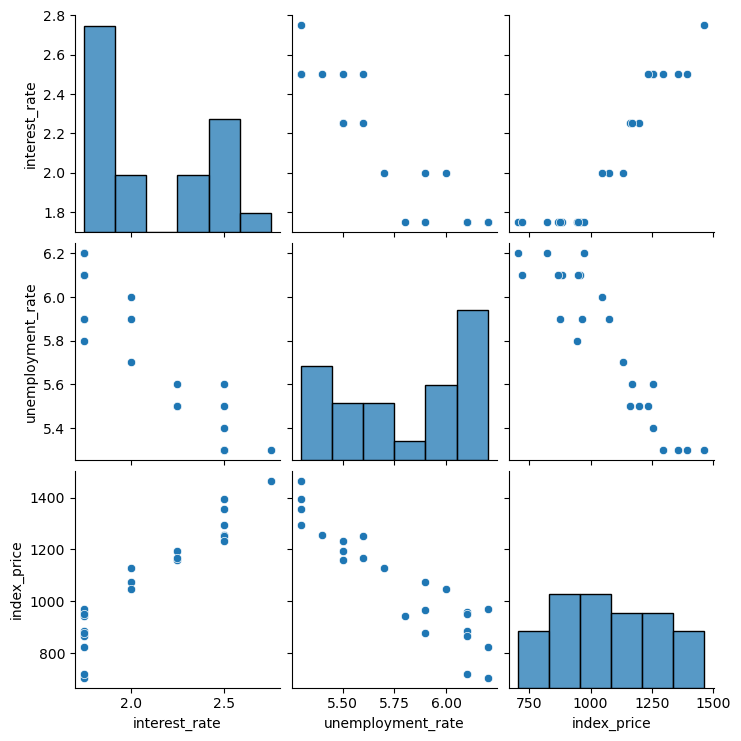

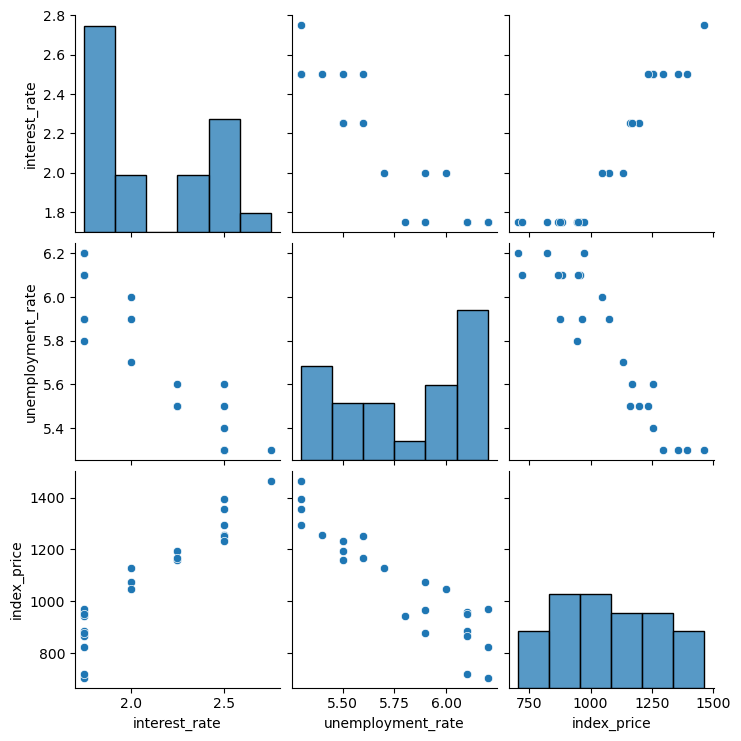

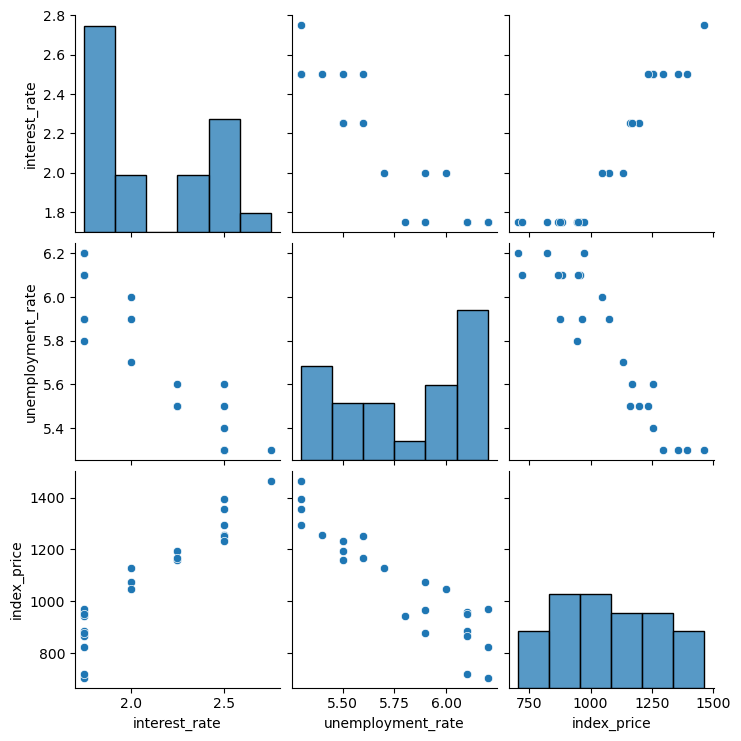

In [36]:
sns.pairplot(df_index)
plt.show()

In [37]:
# understand the correlation between the values
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


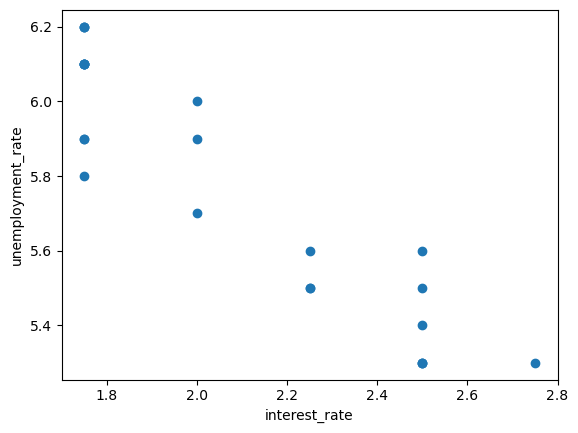

In [42]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'])
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')
plt.show()

# result we got the inverse relationship btw them

In [43]:
# make x and y data as dependent and undependent data
x = df_index.iloc[:,:-1] # all rows first coloon and nxt coon for colums selection
y = df_index.iloc[:,-1]

In [44]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [45]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [46]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [48]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [49]:
import seaborn as sns


In [54]:
sns.regplot(
    x=df_index['interest_rate'],
    y=df_index['unemployment_rate']
)

# not showing



<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

In [56]:
# standard scaleer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Compute mean/std and then transform
X_train = scaler.fit_transform(X_train) 
# Use training parameters to transform new data
X_test = scaler.transform(X_test)

In [58]:
X_train

array([[ 0.55339859, -0.53244666],
       [-0.9486833 ,  0.41597395],
       [ 1.30443953, -1.48086727],
       [-0.9486833 ,  1.36439457],
       [ 1.30443953, -0.53244666],
       [ 1.30443953, -1.48086727],
       [-0.19764235,  0.73211416],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -1.48086727],
       [ 1.30443953, -1.16472707],
       [-0.9486833 ,  1.36439457],
       [-0.9486833 ,  1.04825436],
       [-0.9486833 ,  0.41597395],
       [-0.9486833 ,  1.04825436],
       [ 0.55339859, -0.84858687],
       [-0.19764235, -0.21630646],
       [-0.9486833 ,  0.09983375],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -0.84858687]])

In [57]:
X_test

array([[ 0.55339859, -0.84858687],
       [-0.9486833 ,  1.36439457],
       [ 2.05548048, -1.48086727],
       [-0.9486833 ,  1.04825436],
       [-0.19764235,  0.41597395]])

In [59]:
# LinearRegression
from sklearn.linear_model import LinearRegression



In [60]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [63]:
# cross val score
from sklearn.model_selection import cross_val_score
val_scores = cross_val_score(model,X_train,y_train,scoring='neg_mean_squared_error',cv=5)

In [67]:
val_scores


array([-1606.47408206, -9579.95329208, -7961.60935985, -8392.32547433,
        -773.2668524 ])

In [66]:
np.mean(val_scores)

np.float64(-5662.725812144448)

In [68]:
# predictioin 
y_pred = model.predict(X_test)

In [69]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

6957.10530325883
71.71878409976625
83.40926389351982


In [ ]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
#display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

In [ ]:
# ?assumptions

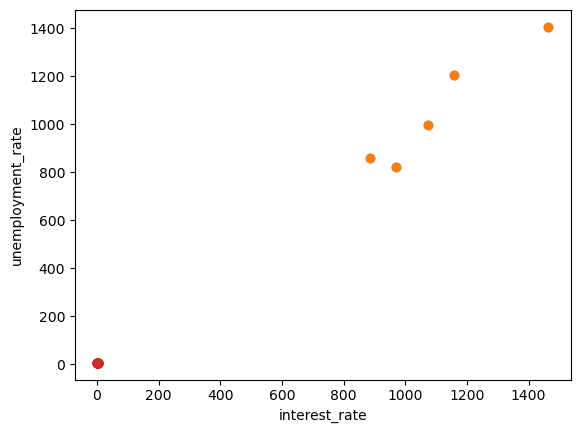

In [71]:
plt.scatter(y_test,y_pred)
plt.show()

In [72]:
residuals=y_test-y_pred
print(residuals)

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64


In [77]:
## Plot this residuals

sns.displot(residuals,kind='kde')

<IPython.core.display.Javascript object>

In [ ]:
# ols 

In [ ]:
# y = b+w1x1+w2x2...
# w1, w2 → coefficients (slopes)
# b → intercept

# 👉 Model ka kaam:
# # In sab ki best values find karna

In [78]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [79]:
model.summary()

D:\anaconda\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Sat, 28 Mar 2026   Prob (F-statistic):                       0.751
Time:                        01:11:37   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            86.6335    647.232      0.134      0.895   -1278.906    1452.173
x2          -114.0486    647.232     -0.176      0.862   -1479.588    1251.491
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.526
Skew:                          -0.369   Prob(JB):                        0.769
Kurtosis:                       2.656   Cond. No.                         4.82
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""